# SVD - Attention Inter/Intra Heads - GPT2

## Introduction

In this notebook I will be exploring the output attention heads from the GPT2 model. In particular, I will be passing a set of batches through the model and exploring two things:

1. For a given layer, the overlap between the different heads for a given set of tokens.
2. For a given head in a given layer, the redundancy across the different dimensions within an individual attention head.

The idea being that if there is sufficient overlap across heads that the use of a compression mechanism/latent space for the outputs might actually be worth it. Also a similar conclusion might be made if there is high levels of redundancy contained within a number of attention heads.

The dataset in question is the wikitext-103-raw-v1 dataset, which is common dataset used to assess a models intelligence. It contains well structured English with a wide vocab. Also this dataset does contain a large number of headers which it is best to ignore for this experiment. It is also suggested that we use 4x the number of tokens as the hidden dimension, the reason being that if there is redundancy in a particular dimension when passing a small batch size the rank may appear artifically lower than in reality. 

## Notebook Setup

In [1]:
%%capture
! pip install transformers==5.7.0 torch==2.9.1 numpy==1.26.4 safetensors==0.7.0 matplotlib==3.10.8 pandas==2.3.3

## Define the necessary libraries

In [2]:
# Base libraries
import random
from tqdm import tqdm

# Maths
import math
import numpy as np
import torch
import pandas as pd
from torch import nn

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset

# Others
from tqdm.notebook import tqdm

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Set the seed

In [4]:
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(42)

## Load the GPT2 Model

In [5]:
# Load the model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

## Load the wikitext 103 dataset

In [6]:
# Load the wikitext 103 dataset
dataset = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation")
texts = dataset["text"]

In [7]:
# Examine the dataset
len(texts)

3760

In [8]:
# Remove any empty texts
texts = [t for t in texts if len(t.strip()) > 100]

In [9]:
# Examine the dataset
len(texts)

1646

In [10]:
# Take a random sample of the texts
batch_size = 128
batch_texts = random.sample(texts, batch_size)

## Examine some of the texts

In [11]:
# Examine the batch of texts
batch_texts[0:5]
batch_texts[-5:-1]

[' " The United Keetoowah Band would like to make it clear that Mr. Churchill IS NOT a member of the Keetoowah Band and was only given an honorary \' associate membership \' in the early 1990s because he could not prove any Cherokee ancestry . " The tribe said that all of Churchill \'s " past , present and future claims or assertions of Keetoowah \' enrollment , \' written or spoken , including but not limited to ; biographies , curriculum vitae , lectures , applications for employment , or any other reference not listed herein , are deemed fraudulent by the United Keetoowah Band . " \n',
 ' McCarty remained in a multi @-@ purpose role in 2010 and was utilized more frequently in the passing game compared to the previous season . He made a reception for a first down following a fake punt in Week 6 . He missed two games later in the season due to a hand injury . In a September 26 game against the Toronto Argonauts , McCarty rushed for 84 yards on 10 carries and two fourth @-@ quarter tou

[' Drawing on the substituent effects compiled over various trials of the reaction , Professor Alison Frontier of the University of Rochester developed a paradigm for " polarized " Nazarov cyclizations in which electron donating and electron withdrawing groups are used to improve the overall selectivity of the reaction . Creation of an effective vinyl nucleophile and vinyl electrophile in the substrate allows catalytic activation with copper triflate and regioselective elimination . In addition , the electron withdrawing group increases the acidity of the α @-@ proton , allowing selective formation of the trans @-@ α @-@ epimer via equilibration . \n',
 ' Additional realignments were completed by the MSHD to move US 2 to its modern lakeshore routing between Gould City and Epoufette in 1941 . The new highway traveled due east from Gould City to Naubinway and then along the lake to Epoufette . The former route through Engadine was turned back to local control as far east as Garnet . From

## Tokenize the input texts

In [12]:
# Define and assign the padding token
tokenizer.pad_token = tokenizer.eos_token

In [13]:
# Tokenize the input data
input_batch = tokenizer(
    batch_texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

In [14]:
# Define the attention mask
attention_mask = input_batch["attention_mask"]

## Extract both the individual attention heads and a layers attention heads

The idea behind this analysis is that we look at each attention head independently and explore the level of redundancy within an attention head, are features being repeated within a singular head. Additionally, are there heads within a layer where there is redundancy? These are the questions we wish to explore.

In [15]:
# Set the whole model to eval mode
_ = model.eval()

In [16]:
class AttentionHeadHook:
    def __init__(self):
        self.across_layer_head_activations = None
        self.individual_head_activations = None
        self.n_heads = 12
        self.head_dim = 64

    def __call__(self, module, input, output):
        # GPT2 Attention output is (attn_output, weights)
        # attn_output -> [batch, seq_len, hidden_size]
        attn_output = output[0]
        batch_size, seq_len, hidden_size = attn_output.shape

        # For Inter-Head Redundancy -> [batch_size * seq_len, hidden_size]
        self.across_layer_head_activations = attn_output.reshape(-1, hidden_size)
        
        # For Individual Head Redundancy -> [batch_size, seq_len, n_heads, head_dim] -> [n_heads=12, (batch_size * seq_len), head_dim=64]
        heads = attn_output.reshape(batch_size, seq_len, self.n_heads, self.head_dim)
        self.individual_head_activations = heads.permute(2, 0, 1, 3).reshape(self.n_heads, -1, self.head_dim)

In [17]:
# Register hooks for all layers' output projections
hooks = []
for i in range(model.config.num_hidden_layers):
    hook = AttentionHeadHook()
    _ = model.transformer.h[i].attn.register_forward_hook(hook)
    hooks.append(hook)

In [18]:
# Pass data through the model
with torch.no_grad():
    _ = model(**input_batch)

## Extract the individual and layerwise head activations

In [19]:
# Examine some of the data
hooks[0].across_layer_head_activations.shape
hooks[0].individual_head_activations.shape

torch.Size([46848, 768])

torch.Size([12, 46848, 64])

In [20]:
# Define the hidden sizes
layer_dim = hooks[0].across_layer_head_activations.shape[-1]
head_dim = hooks[0].individual_head_activations.shape[-1]

In [21]:
# Filter padding from hooks
for hook in tqdm(hooks, total=len(hooks)):
    
    # Convert MLX arrays to NumPy for filtering
    across_layer_head_activations_np = np.array(hook.across_layer_head_activations)
    individual_head_activations_np = np.array(hook.individual_head_activations)
    mask_np = np.array(attention_mask).flatten()
    
    # Use NumPy's boolean indexing to keep only non-padding tokens (where mask == 1)
    across_layer_head_filtered_activations_np = across_layer_head_activations_np[mask_np > 0]
    individual_head_filtered_activations_np = individual_head_activations_np[:, mask_np > 0, :]
    
    # Convert back to MLX for the SVD
    hook.across_layer_head_activations = np.array(across_layer_head_filtered_activations_np)
    hook.individual_head_activations = np.array(individual_head_filtered_activations_np)

  0%|          | 0/12 [00:00<?, ?it/s]

In [22]:
# Extract the head and layer head data
flattened_layer_head_activations_list = [item.across_layer_head_activations for item in hooks]
flattened_head_activations_list = [item.individual_head_activations for item in hooks]

flattened_layer_head_activations_list[0].shape
flattened_head_activations_list[0].shape

len(flattened_layer_head_activations_list)
len(flattened_head_activations_list)

(19757, 768)

(12, 19757, 64)

12

12

## Apply SVD

## Calculate the effective rank of each activation matrix

### Retension based rank (Energy Cutoff)

This is a threshold based matric, which focuses on the question, how many singular values do I need to preserve at least $x\%$ of the matrices total energy. This allows for the direct calculation of compressibility of a matrix.

In particular, in ML the singular value represents the stretch of each dimension, but S squared represents the energy (or variance) contained in that dimension.

In [23]:
def calculate_retension_based_rank(S, threshold_list):
    """
    This function take a matrices singular values and estimate the retension based rank for a list of thresholds.
    It essentially takes the singular values, squares them to represent each Wo dimensions variance and subsequently, calculates 
    the cumulative percentage energy values. Then taking the thresholds we find the number of dimensions that combine to cross the 
    pre-defined minimum thresholds.
    """

    # Calculate the cumulative percentage energy values -> Cumulative sum / total energy (S**2)
    cumulative_energy = np.cumsum(S**2) / np.sum(S**2)

    # Find smallest k such that cumulative energy >= alpha
    retention_based_rank_values = [{threshold: np.searchsorted(cumulative_energy, threshold) + 1} for threshold in threshold_list]

    return retention_based_rank_values

### Entropy based effective rank

Given singular values $S$ of a matrix $W$, we want to calculate the effective rank, such that:

- If the spectrum is uniform → rank is high
- If a few singular values dominate → rank is low
- If one singular value dominates → rank ≈ 1
- If all singular values are equal → rank = full rank

The entropy-based effective rank satisfies all of these.

In [24]:
def calculate_effective_rank(S):
    """
    Calculating the entropy based effective rank value. Remember that S**2 represents the energy of that dimension and thus we initially 
    calculate a energy based probability distribution which sums to 1. We then measure the uncertainty via the entropy calculation. We then
    convert back to a rank value by taking the exp.
    """

    # Calculate the energy based probability
    p = (S**2) / np.sum(S**2)

    # Calculate the Shannon entropy (log scale)
    H = -np.sum(p * np.log(p))
    
    # Calculate the effective rank (R scale)
    entropy_based_effective_rank = np.exp(H)

    return entropy_based_effective_rank

In [25]:
def calculate_SVD_rank_metrics(H, use_tqdm=True):
    """
    First calculate the SVD and then calculate the retension based rank value and entropy baesd effective rank values. 
    """

    # Create a list to store the results
    svd_layers = []

    # Create a wrapper that either yields tqdm or a standard range
    head_enumerate = tqdm(enumerate(H), total=len(H)) if use_tqdm else enumerate(H)

    # For each layers concat attention heads matrix
    for layer, h in head_enumerate:
    
        # Calculate the SVD
        U, S, VT = np.linalg.svd(h, full_matrices=False)
    
        # Calculate the retension based rank values
        retension_based_rank_values = calculate_retension_based_rank(S, [0.99, 0.999])    
    
        # Calculate the entropy based effective rank
        entropy_based_effective_rank = calculate_effective_rank(S)
        
        # Store the results
        svd_layers.append({
            "layer": layer,
            "U": U,
            "S": S,
            "VT": VT,
            "retension_based_rank_values": retension_based_rank_values,
            "entropy_based_effective_rank": entropy_based_effective_rank,
        })

    return svd_layers

## Inter Head SVD

Here we will explore the dimension redundancy across attention heads across all layers of the GPT2 model. In particular, we look at all heads stacked together (16 * 64 = 1024). If each head is independent then we would expect the effective rank to be close to 1024, otherwise, values lower than this would suggest a level of overlap between the heads.

In [26]:
def df_expand(svd_head_layer):
    """
    Prepare the SVD dataframe for plotting.
    """
    svd_layers_df = pd.DataFrame(svd_head_layer)
    svd_layers_df_expanded = pd.concat([
        svd_layers_df.drop(columns='retension_based_rank_values'),
        svd_layers_df['retension_based_rank_values'].apply(lambda lst: {k: v for d in lst for k, v in d.items()}).apply(pd.Series)
    ], axis=1)
    return svd_layers_df_expanded.rename(columns={0.99: 'r99', 0.999: 'r99.9'})

In [27]:
# Calculate the entropy based effective rank and also retention based rank values
svd_layers = calculate_SVD_rank_metrics(flattened_layer_head_activations_list)

  0%|          | 0/12 [00:00<?, ?it/s]

In [28]:
# Prepare the data for plotting
svd_layers_df_expanded = df_expand(svd_layers)

## Plot the curves of the rank curves

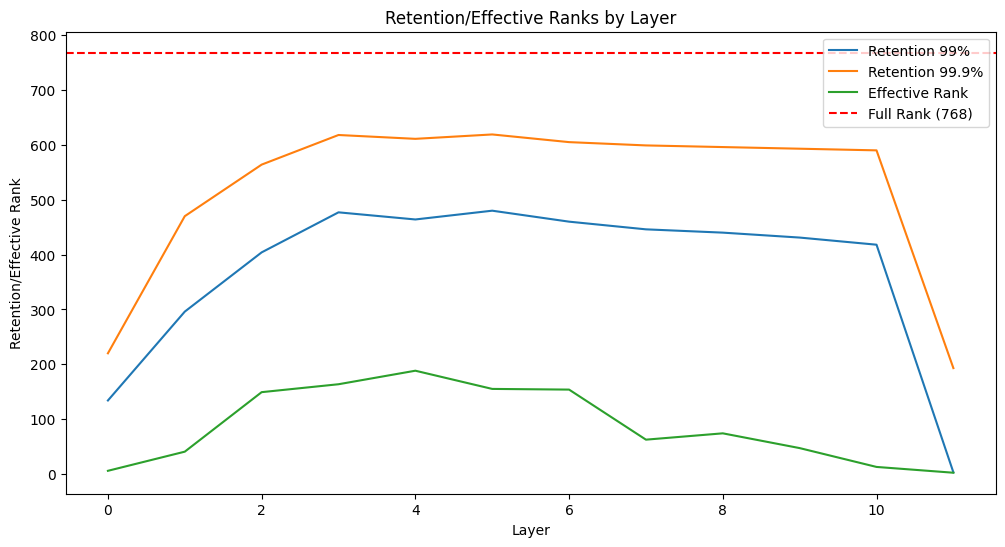

In [29]:
# Plot the  
ax = svd_layers_df_expanded.plot(x='layer', y=['r99', 'r99.9', 'entropy_based_effective_rank'], figsize=(12, 6))

# Add a custom horizontal line
_ = plt.axhline(y=layer_dim, color='red', linestyle='--', label='Threshold Line')

# Add titles, labels and legend
_ = plt.ylabel('Retention/Effective Rank')
_ = plt.xlabel('Layer')
_ = plt.title('Retention/Effective Ranks by Layer')
_ = ax.legend(['Retention 99%', 'Retention 99.9%', "Effective Rank", f"Full Rank ({layer_dim})"])
plt.show()

## Calculate the average value across the different layers

In [30]:
# Calculate and print with 2-digit precision
print(f"Average Retention 99%: {svd_layers_df_expanded['r99'].mean():.2f}")
print(f"Average Retention 99.9%: {svd_layers_df_expanded['r99.9'].mean():.2f}")
print(f"Average Effective Rank (Entropy): {svd_layers_df_expanded['entropy_based_effective_rank'].mean():.2f}")

Average Retention 99%: 371.08
Average Retention 99.9%: 523.17
Average Effective Rank (Entropy): 87.94


The level of dimension redundancy between attention heads across the different layers of the model can be seen above. It is incredible to see that on average across the different layers of the model the effective rank is 49/768 (11.45%), suggesting that the model is really redundant (as we saw in prior experiments). Additionally, it is also worth pointing out that these values are even lower at the early and late layers of the model.

## Intra Head SVD

Next, I will explore the individual head redundancy levels across the different dimensions of each attention head.

In [31]:
# Calculate the entropy based effective rank and also retention based rank values
svd_head_layers = [calculate_SVD_rank_metrics(item, use_tqdm=False) for item in tqdm(flattened_head_activations_list)]

  0%|          | 0/12 [00:00<?, ?it/s]

In [32]:
# Prepare each dataset for plotting
svd_layers_heads_df_expanded = [df_expand(item) for item in tqdm(svd_head_layers)]

  0%|          | 0/12 [00:00<?, ?it/s]

## Plot the curves of the rank curves

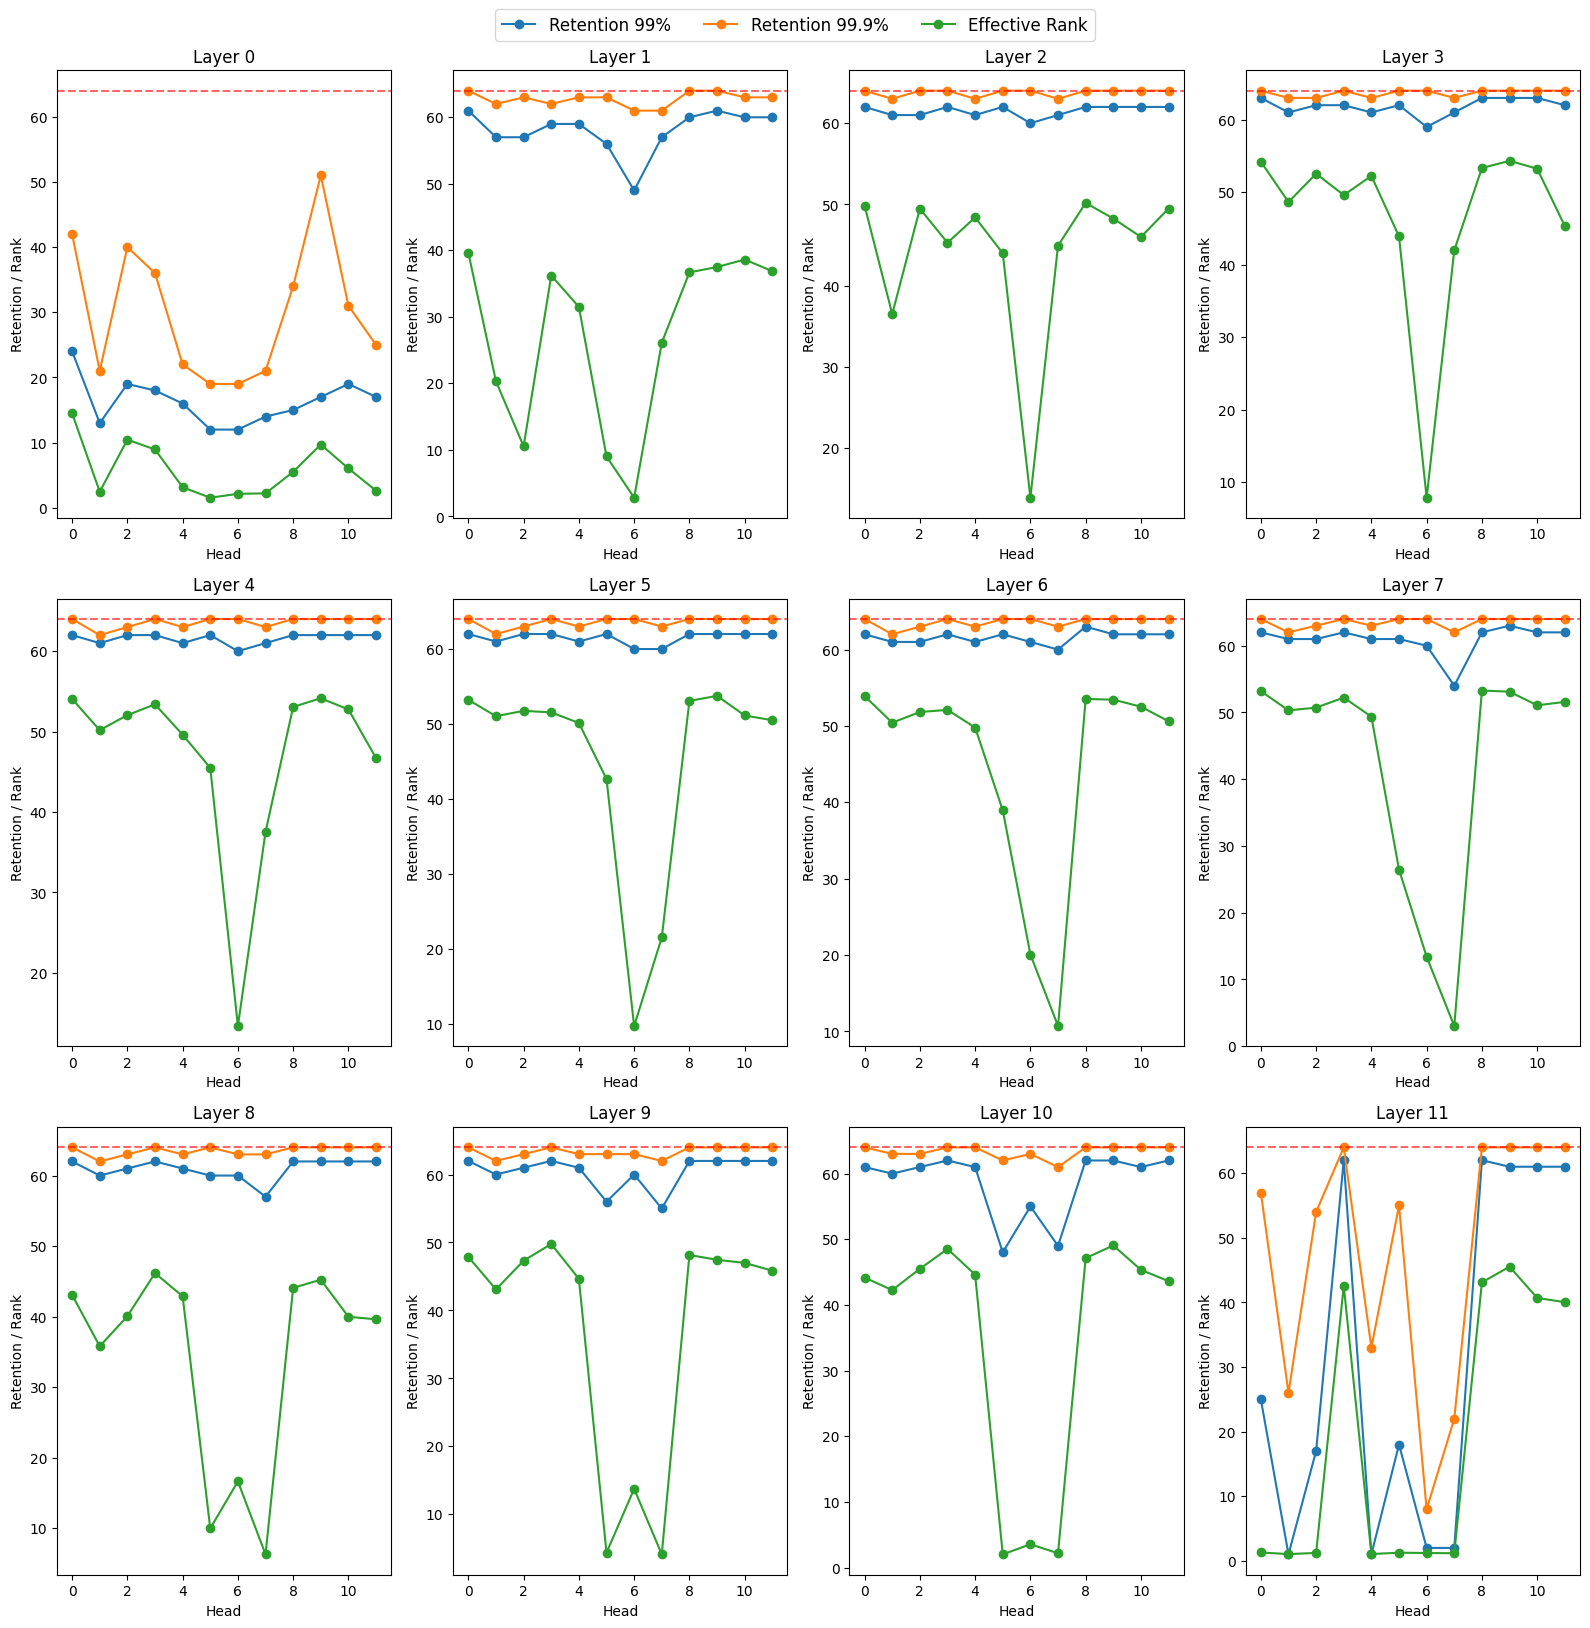

In [33]:
# Create a figure with a 6x4 grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(len(svd_layers_heads_df_expanded)):
    ax = axes[i]
    # Plotting each layer's specific DataFrame
    _ = svd_layers_heads_df_expanded[i].plot(
        x='layer', 
        y=['r99', 'r99.9', 'entropy_based_effective_rank'], 
        ax=ax, 
        legend=False, 
        marker='o'
    )
    
    # Red threshold line
    _ = ax.axhline(y=head_dim, color='red', linestyle='--', alpha=0.6)
    
    # Formatting
    _ = ax.set_title(f'Layer {i}')
    _ = ax.set_xlabel('Head')
    _ = ax.set_ylabel('Retention / Rank')

# Create a single legend at the top for the entire figure
handles, labels = axes[0].get_legend_handles_labels()
_ = fig.legend(handles, ['Retention 99%', 'Retention 99.9%', 'Effective Rank', f'Full Rank ({head_dim})'], 
           loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, fontsize='large')

plt.tight_layout()
plt.show()

There does appear to be a pattern around the 6-8 heads across layers 3-12, which is interesting but unclear as to why this is the case. Layers 0 and 11 also appear to have higher levels of redundancy compared to the other layers.

## Examine the overlap across attention heads

Linear Centered Kernel Alignment (CKA) is an efficient way to measure how similar the internal representations of a neural network are, even if they are rotated or scaled differently. Its range is from 0 to 1 with higher values representing higher redundancy.

In [34]:
def linear_cka(X, Y):
    """
    X, Y: (N, D) - Features for two heads (e.g., 46208 x 64)
    """
    # Convert to tensors of float64
    X = torch.from_numpy(X).double()
    Y = torch.from_numpy(Y).double()
    
    # Center the columns (features)
    X = X - X.mean(dim=0)
    Y = Y - Y.mean(dim=0)
    
    # Compute HSIC: Frobenius norm squared of (Y^T @ X)
    # This results in a small (D x D) matrix multiplication
    dot_product = torch.linalg.norm(Y.T @ X, ord='fro')**2
    
    # Compute Normalization (Denominators)
    norm_x = torch.linalg.norm(X.T @ X, ord='fro')
    norm_y = torch.linalg.norm(Y.T @ Y, ord='fro')
    
    return dot_product / (norm_x * norm_y)

def compute_head_similarity_matrix(head_data):
    """
    head_data: torch.Size([16, 46208, 64])
    """
    num_heads = head_data.shape[0]
    cka_matrix = np.zeros((num_heads, num_heads))
    
    for i in range(num_heads):
        for j in range(i, num_heads):
            score = linear_cka(head_data[i], head_data[j])
            cka_matrix[i, j] = score
            cka_matrix[j, i] = score # Symmetric
            
    return cka_matrix

In [35]:
def plot_heatmap(ax, matrix, layer_id=None):
    """
    Plots the Linear CKA similarity matrix and calculates/displays the average head overlap.
    """
    # Calculate overlap
    num_heads = matrix.shape[0]
    upper_tri = matrix[np.triu_indices(num_heads, k=1)]
    avg_overlap = float(f"{upper_tri.mean():.4f}")
    
    # Plot heatmap on the specific subplot axis
    sns.heatmap(matrix, annot=True, cmap='viridis', fmt=".2f", vmin=0, vmax=1, ax=ax, cbar=True)
    ax.set_title(f"Layer {layer_id}\nAvg Overlap: {avg_overlap:.4f}", fontsize=12)
    ax.set_xlabel("Head Index")
    ax.set_ylabel("Head Index")

    return ax, avg_overlap

In [36]:
def plot_all_layers_grid(matrix_list, cols=2):
    """
    Plots all CKA matrices in a single grid.
    """
    avg_overlap_list = []
    num_layers = len(matrix_list)
    rows = math.ceil(num_layers / cols)
    
    # Adjust figsize based on grid size (width, height)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))
    axes = axes.flatten()
    
    for layer_id, matrix in enumerate(matrix_list):
        ax = axes[layer_id]
        ax, avg_overlap = plot_heatmap(ax, matrix, layer_id=layer_id)
        avg_overlap_list.append(avg_overlap)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return avg_overlap_list

In [37]:
# Calculate each layers head similarity
layer_head_similarity = [compute_head_similarity_matrix(item) for item in tqdm(flattened_head_activations_list)]

  0%|          | 0/12 [00:00<?, ?it/s]

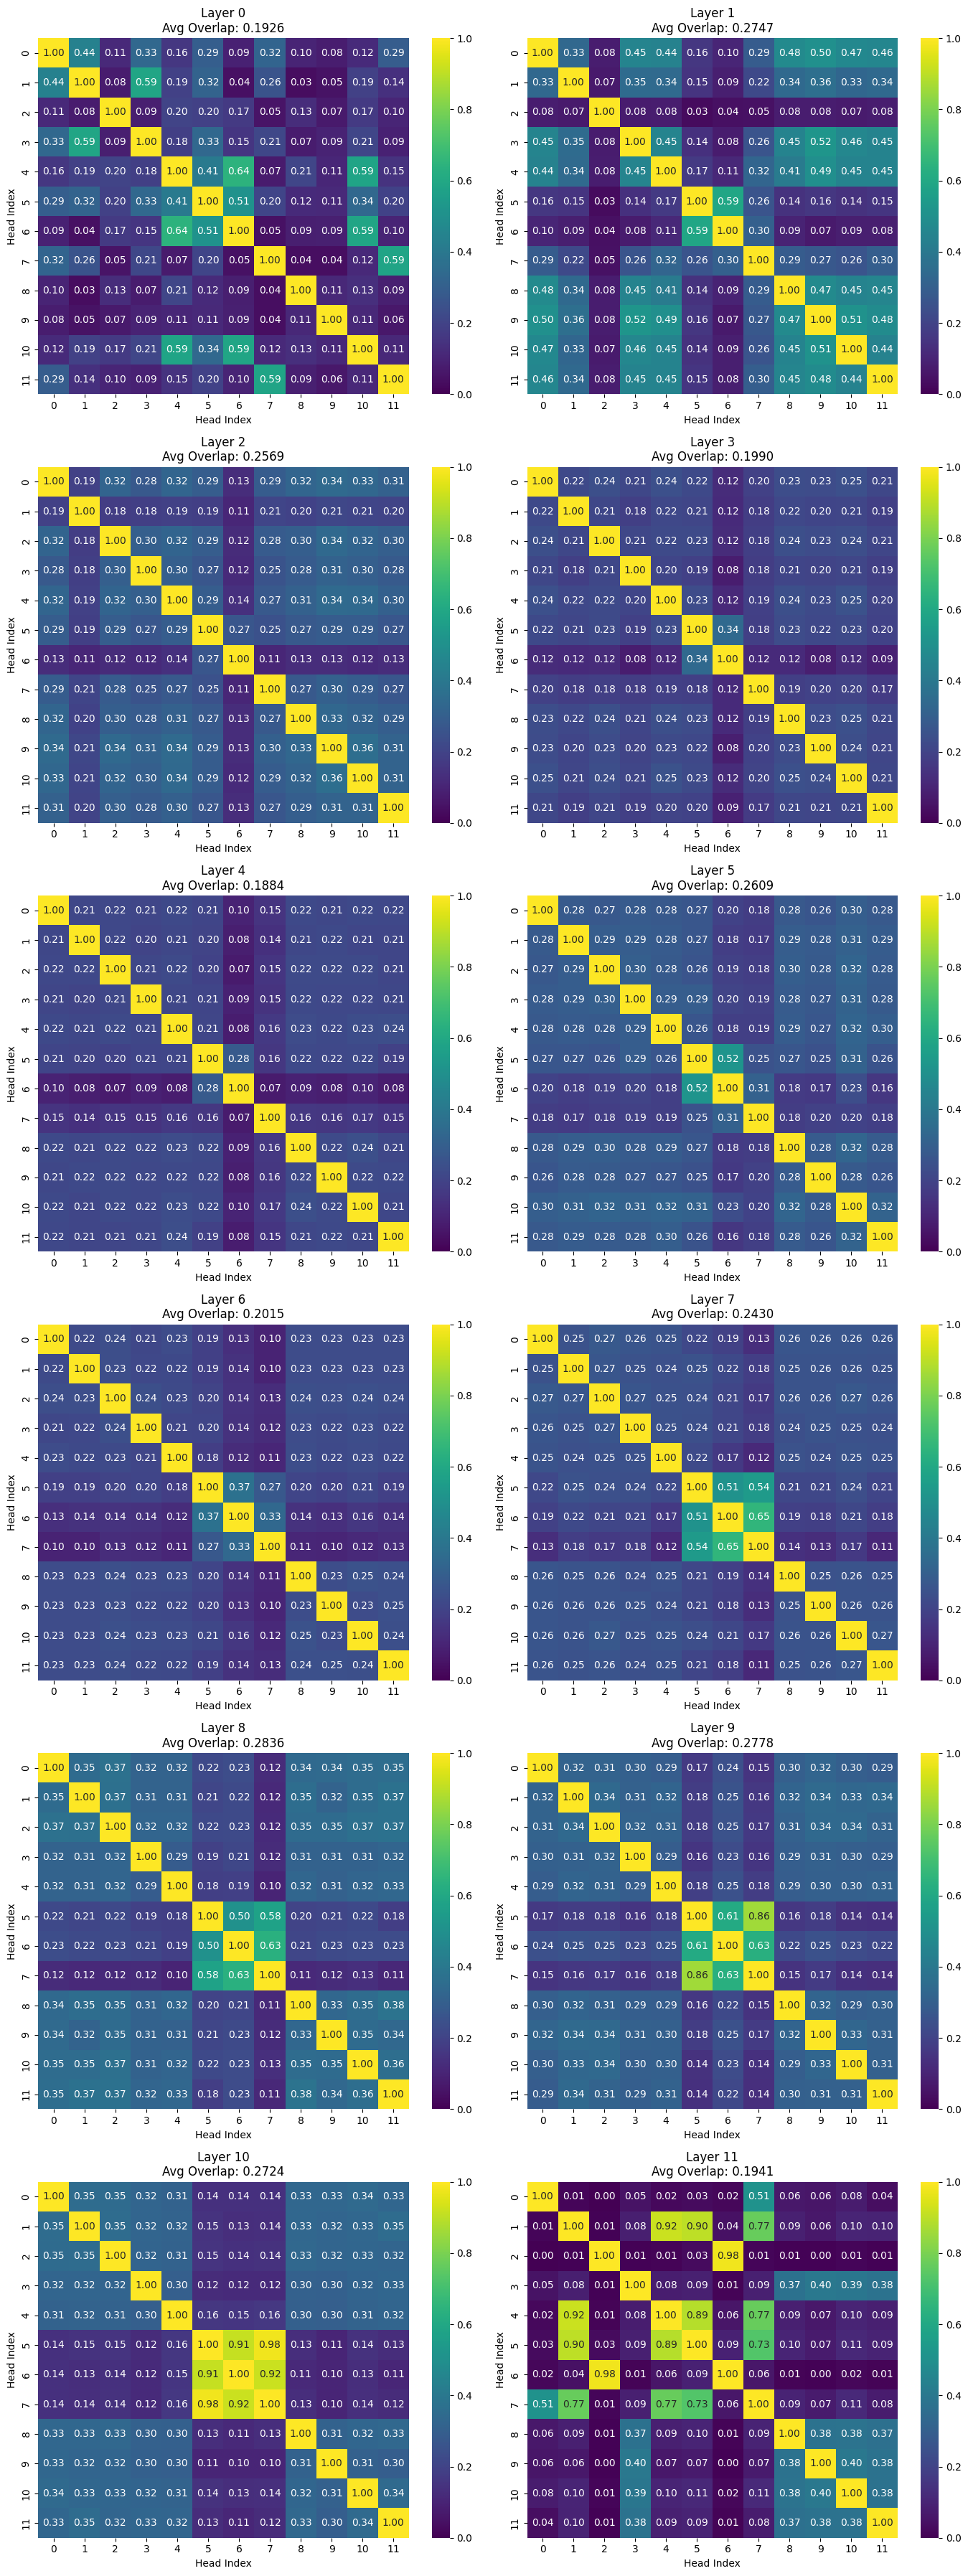

In [38]:
# Plot the attention head overlap heatmaps
avg_overlap_list = plot_all_layers_grid(layer_head_similarity, cols=2)

In [39]:
# Examine the overlap scores
avg_overlap_list
np.mean(avg_overlap_list)

[0.1926,
 0.2747,
 0.2569,
 0.199,
 0.1884,
 0.2609,
 0.2015,
 0.243,
 0.2836,
 0.2778,
 0.2724,
 0.1941]

0.23707500000000004

Some heads show medium/high levels of simlarity across all layers with the final two layers showing a larger qualtity of heads that are very similar (albeit at low quantities).

## Conclusion

Overall, it is clear that there is a high level of dimension redundancy both in attention head and across attention head across the different layers of the model. With particularly high levels of redundancy in layers 0 and 11. It is also worth noting that the across head effective rank was very low at 6.8% on average which suggests major inefficiency. Lastly, the GPT2 model also exhibits clear attention head overlap across the different layers of the model (in particular layers 1/2), which would suggest that model does not have great attention head diversity (learning diversity).